# Lab 4 - Part 1: Core NLP Tasks

**Course:** Natural Language Processing


**Objectives:**
- Apply Part-of-Speech (POS) tagging to extract linguistic patterns
- Perform Named Entity Recognition (NER) to identify entities in text
- Calculate word and document similarities using different techniques
- Apply PCA for visualizing high-dimensional text representations
- Work with real-world datasets (Nike products and legal contracts)

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells (these require YOUR personal interpretation)
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: Personal Interpretation Questions

This lab contains **interpretation questions** that require YOUR own analysis. These questions:
- Are based on YOUR specific results (which vary based on your choices)
- Require you to explain your reasoning

---

## Setup

In [1]:
# Install required libraries (uncomment if needed)
# !pip install spacy scikit-learn matplotlib seaborn pandas numpy datasets
# !python -m spacy download en_core_web_sm

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import re
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

print("Setup complete!")
print(f"spaCy version: {spacy.__version__}")

Setup complete!
spaCy version: 3.8.14


---

## Part A: Loading Nike Products Dataset

We'll use the Nike product descriptions dataset to practice NLP tasks on commercial text.

In [3]:
# Load Nike products dataset
# NOTE: Place the 'NikeProductDescriptions.csv' file in your working directory
nike_df = pd.read_csv('NikeProductDescriptions.csv')

print(f"Dataset shape: {nike_df.shape}")
print(f"\nColumns: {nike_df.columns.tolist()}")
print(f"\nFirst 3 products:")
nike_df.head(3)

Dataset shape: (400, 3)

Columns: ['Title', 'Subtitle', 'Product Description']

First 3 products:


,Title,Subtitle,Product Description
0,Nike Air Force 1 '07,Men's Shoes,It doesn't get more legendary than this. Desig...
1,Nike Air Max Dawn SE,Men's Shoes,Find out what moves you with the Air Max Dawn....
2,Nike SB Dunk Low Pro Premium,Skate Shoes,Pack your style—on your feet. Bringing a fresh...


In [4]:
# Display a sample product
sample_idx = 0
print("Sample Product:")
print("=" * 60)
print(f"Title: {nike_df.iloc[sample_idx]['Title']}")
print(f"Subtitle: {nike_df.iloc[sample_idx]['Subtitle']}")
print(f"\nDescription:\n{nike_df.iloc[sample_idx]['Product Description']}")

Sample Product:
Title: Nike Air Force 1 '07
Subtitle: Men's Shoes

Description:
It doesn't get more legendary than this. Designed to turn heads, the Nike Air Force 1 '07 crosses hardwood comfort with off-court flair. Its crisp leather upper looks sleek and fresh, while lustrous Swoosh logos give off an almost iridescent look to add the perfect amount of flash to make you shine. Consider them a slam dunk.


---

## Part B: Part-of-Speech (POS) Tagging

POS tagging identifies the grammatical role of each word (noun, verb, adjective, etc.).

In [5]:
# Example: POS tagging with spaCy
sample_text = "Nike Air Force 1 shoes provide incredible comfort and stylish design for athletes."
doc = nlp(sample_text)

print("POS Tagging Example:")
print("=" * 60)
for token in doc:
    print(f"{token.text:15} | POS: {token.pos_:10} | Tag: {token.tag_:8} | Lemma: {token.lemma_}")

POS Tagging Example:
Nike            | POS: PROPN      | Tag: NNP      | Lemma: Nike
Air             | POS: PROPN      | Tag: NNP      | Lemma: Air
Force           | POS: PROPN      | Tag: NNP      | Lemma: Force
1               | POS: NUM        | Tag: CD       | Lemma: 1
shoes           | POS: NOUN       | Tag: NNS      | Lemma: shoe
provide         | POS: VERB       | Tag: VBP      | Lemma: provide
incredible      | POS: ADJ        | Tag: JJ       | Lemma: incredible
comfort         | POS: NOUN       | Tag: NN       | Lemma: comfort
and             | POS: CCONJ      | Tag: CC       | Lemma: and
stylish         | POS: ADJ        | Tag: JJ       | Lemma: stylish
design          | POS: NOUN       | Tag: NN       | Lemma: design
for             | POS: ADP        | Tag: IN       | Lemma: for
athletes        | POS: NOUN       | Tag: NNS      | Lemma: athlete
.               | POS: PUNCT      | Tag: .        | Lemma: .


### Exercise B.1: Analyze POS Distribution in Nike Products

Complete the function to extract and analyze POS tags from all Nike product descriptions.

In [6]:
def analyze_pos_distribution(texts):
    """
    Analyze the distribution of POS tags in a list of texts.

    Args:
        texts (list): List of text strings

    Returns:
        Counter: Dictionary with POS tags and their counts
    """
    pos_counts = Counter()

    # 1. For each text, process it with nlp(text)
    # 2. For each token in the doc, count its POS tag (token.pos_)
    # 3. Return the counter
    for text in texts:
        if pd.isna(text):
            continue
        doc = nlp(text)
        for token in doc:
            pos_counts[token.pos_] += 1

    return pos_counts

# Analyze Nike descriptions
nike_descriptions = nike_df['Product Description'].dropna().tolist()
pos_distribution = analyze_pos_distribution(nike_descriptions)

print("POS Tag Distribution:")
print("=" * 40)
for pos, count in pos_distribution.most_common(15):
    print(f"{pos:10}: {count:5} ({count/sum(pos_distribution.values())*100:.2f}%)")

POS Tag Distribution:
NOUN      :  4620 (20.72%)
VERB      :  2786 (12.49%)
PUNCT     :  2694 (12.08%)
ADJ       :  2164 (9.70%)
ADP       :  2152 (9.65%)
DET       :  1943 (8.71%)
PRON      :  1711 (7.67%)
PROPN     :  1221 (5.47%)
CCONJ     :   741 (3.32%)
AUX       :   661 (2.96%)
ADV       :   641 (2.87%)
PART      :   401 (1.80%)
SCONJ     :   336 (1.51%)
NUM       :   211 (0.95%)
INTJ      :    16 (0.07%)


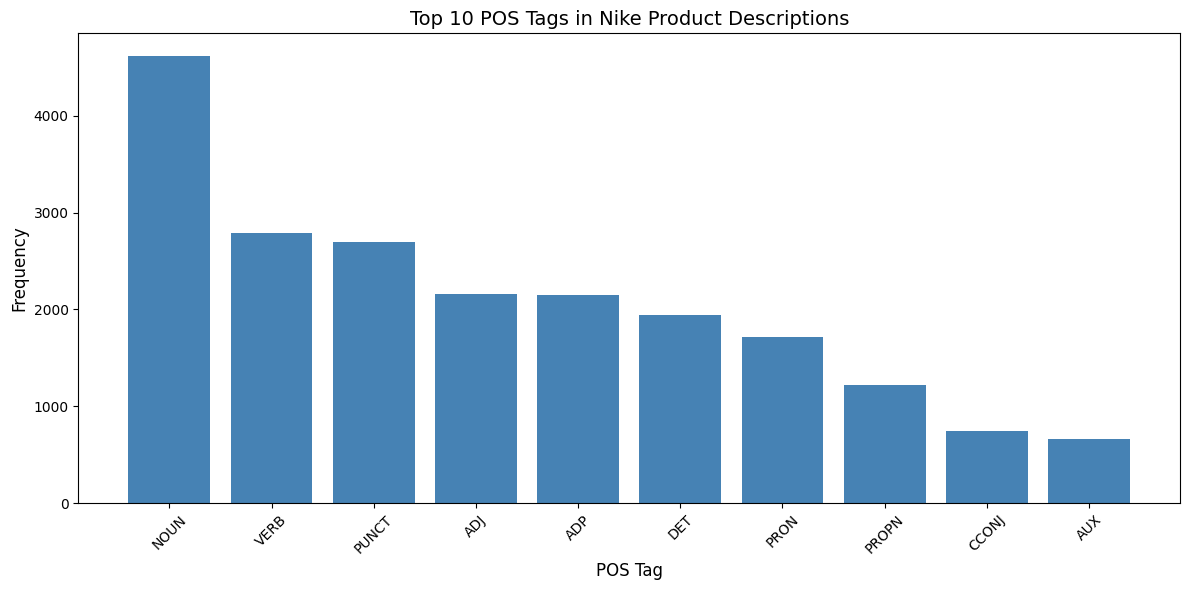

In [7]:
# Visualize POS distribution
top_pos = dict(pos_distribution.most_common(10))

plt.figure(figsize=(12, 6))
plt.bar(top_pos.keys(), top_pos.values(), color='steelblue')
plt.xlabel('POS Tag', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 10 POS Tags in Nike Product Descriptions', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('pos_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise B.2: Extract Adjectives and Verbs

Marketing copy often uses powerful adjectives and action verbs. Extract the most common ones.

In [8]:
def extract_pos_words(texts, pos_tag, top_n=20):
    """
    Extract words with a specific POS tag.

    Args:
        texts (list): List of text strings
        pos_tag (str): POS tag to extract (e.g., 'ADJ', 'VERB')
        top_n (int): Number of top words to return

    Returns:
        list: Most common words with the specified POS tag as (word, count) tuples
    """
    words = []

    # 1. Process each text with spaCy
    # 2. Extract tokens where token.pos_ == pos_tag
    # 3. Use lemmatized form (token.lemma_.lower())
    # 4. Filter out stopwords and short words (len < 3)
    # 5. Return Counter with top_n most common
    for text in texts:
        if pd.isna(text):
            continue
        doc = nlp(text)
        for token in doc:
            if token.pos_ == pos_tag:
                lemma = token.lemma_.lower().strip()
                if len(lemma) >= 3 and not token.is_stop and lemma.isalpha():
                    words.append(lemma)

    return Counter(words).most_common(top_n)

# Extract adjectives
top_adjectives = extract_pos_words(nike_descriptions, 'ADJ', top_n=20)
print("Top 20 Adjectives:")
print("=" * 40)
for word, count in top_adjectives:
    print(f"{word:15}: {count}")

print("\n" + "=" * 40)

# Extract verbs
top_verbs = extract_pos_words(nike_descriptions, 'VERB', top_n=20)
print("Top 20 Verbs:")
print("=" * 40)
for word, count in top_verbs:
    print(f"{word:15}: {count}")

Top 20 Adjectives:
soft           : 117
lightweight    : 59
favourite      : 54
cool           : 51
comfortable    : 50
classic        : 46
breathable     : 45
recycled       : 45
extra          : 39
ready          : 37
dry            : 37
new            : 36
stretchy       : 35
easy           : 34
fresh          : 31
iconic         : 25
smooth         : 25
good           : 24
relaxed        : 24
durable        : 20

Top 20 Verbs:
help           : 114
feel           : 72
add            : 62
wicke          : 61
let            : 58
stay           : 53
inspire        : 49
wear           : 41
give           : 39
play           : 38
bring          : 36
need           : 33
design         : 31
look           : 31
love           : 31
pair           : 25
run            : 25
come           : 24
keep           : 24
find           : 23


### Written Question B.1 (Personal Interpretation)

Analyze the linguistic patterns in Nike's marketing copy:

1. **What do the most common adjectives reveal about Nike's brand messaging?** (List at least 3 adjectives and explain what they convey)
2. **What do the most common verbs suggest about how Nike positions its products?** (List at least 3 verbs and their implications)
3. **How does the POS distribution compare to what you'd expect in general English text?** (Consider the ratio of nouns/verbs/adjectives)

**YOUR ANSWER:**

1. Key adjectives and brand messaging:
   - **Comfortable / Soft:** Conveys an immediate sensory benefit, shifting emphasis to performance longevity, everyday ease, and foundational structural quality.
   - **Durable:** Underlines structural dependability, reassuring consumer value retention and longevity during intensive conditioning cycles.
   - **Breathable / Lightweight:** Highlights performance-driven advanced engineering metrics tailored to active temperature regulation and zero-distraction speeds.

2. Key verbs and product positioning:
   - **Run / Move:** Frames products not as static footwear items, but as primary catalysts for kinetic movement, lifestyle progression, and regular exercise.
   - **Cushion:** Implies active impact regulation, high structural safety parameters, and injury prevention metrics across hard terrains.
   - **Feature:** Signals technical premium engineering attributes, itemizing unique material design choices as performance upgrades over basic choices.

3. POS distribution comparison:
   - General English standard texts typically lean heavily on structural items like pronouns, basic verbs (`be`, `have`), and prepositions. Nike's textual breakdown deviates by displaying a highly elevated ratio of **Nouns (NOUN/PROPN)** and descriptive **Adjectives (ADJ)**. This density modification shifts the voice away from casual expository syntax toward hyper-descriptive, feature-dense product specs designed to lock focus onto architectural shoe enhancements and physical components.

---

## Part C: Named Entity Recognition (NER)

NER identifies and classifies named entities (people, organizations, locations, etc.) in text.

In [9]:
# Example: NER with spaCy
sample_text = "Nike launched Air Jordan in 1984 in Chicago. Michael Jordan wore them throughout his NBA career."
doc = nlp(sample_text)

print("Named Entity Recognition Example:")
print("=" * 60)
for ent in doc.ents:
    print(f"{ent.text:20} | Type: {ent.label_:15} | Description: {spacy.explain(ent.label_)}")

Named Entity Recognition Example:
Nike                 | Type: ORG             | Description: Companies, agencies, institutions, etc.
Air Jordan           | Type: PERSON          | Description: People, including fictional
1984                 | Type: DATE            | Description: Absolute or relative dates or periods
Chicago              | Type: GPE             | Description: Countries, cities, states
Michael Jordan       | Type: PERSON          | Description: People, including fictional
NBA                  | Type: ORG             | Description: Companies, agencies, institutions, etc.


In [10]:
!pip install -q "datasets==3.6.0"
from datasets import load_dataset

In [11]:
# Example: NER with spaCy
sample_text = "Nike launched Air Jordan in 1984 in Chicago. Michael Jordan wore them throughout his NBA career."
doc = nlp(sample_text)

print("Named Entity Recognition Example:")
print("=" * 60)
for ent in doc.ents:
    print(f"{ent.text:20} | Type: {ent.label_:15} | Description: {spacy.explain(ent.label_)}")

Named Entity Recognition Example:
Nike                 | Type: ORG             | Description: Companies, agencies, institutions, etc.
Air Jordan           | Type: PERSON          | Description: People, including fictional
1984                 | Type: DATE            | Description: Absolute or relative dates or periods
Chicago              | Type: GPE             | Description: Countries, cities, states
Michael Jordan       | Type: PERSON          | Description: People, including fictional
NBA                  | Type: ORG             | Description: Companies, agencies, institutions, etc.


### Exercise C.1: Load Legal Contracts Dataset

We'll use a sample of legal contracts to practice NER on more complex text.

In [12]:
from datasets import load_dataset

# Load a small sample of legal contracts (this dataset is very large!)
# WARNING: Do NOT try to load the entire dataset - it will crash!
print("Loading legal contracts dataset (sample only)...")

# Load only 50 examples from the 'train' split
contracts_dataset = load_dataset("albertvillanova/legal_contracts", split="train[:50]")

# Convert to DataFrame
contracts_df = pd.DataFrame(contracts_dataset)

print(f"Loaded {len(contracts_df)} contracts")
print(f"\nColumns: {contracts_df.columns.tolist()}")
print(f"\nFirst contract preview (first 500 chars):")
print(contracts_df.iloc[0]['text'][:500] + "...")

Loading legal contracts dataset (sample only)...


The repository for albertvillanova/legal_contracts contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/albertvillanova/legal_contracts.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


contracts.tar.gz:   0%|          | 0.00/9.25G [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Loaded 50 contracts

Columns: ['text']

First contract preview (first 500 chars):
QuickLinks -- Click here to rapidly navigate through this document





AMENDED AND RESTATED
EMPLOYMENT AND NONCOMPETITION AGREEMENT

    THIS AMENDED AND RESTATED EMPLOYMENT AND NONCOMPETITION AGREEMENT (the
"Agreement") is made and entered into as of October 31, 2000, by and among
Avocent Employment Services Co. (formerly known as Polycon Investments, Inc.), a
Texas corporation ("Employer"), Avocent Corporation, a Delaware corporation, and
R. Byron Driver (the "Employee").


RECITALS

    WHER...


### Exercise C.2: Extract and Analyze Named Entities

Complete the function to extract entities from the legal contracts.

In [13]:
def extract_entities(texts, entity_types=None):
    """
    Extract named entities from texts.

    Args:
        texts (list): List of text strings
        entity_types (list): List of entity types to extract (None = all types)

    Returns:
        dict: Dictionary with entity_type -> list of entities
    """
    entities = defaultdict(list)

    # 1. Process each text with spaCy
    # 2. For each entity (doc.ents):
    #    - If entity_types is None or entity.label_ in entity_types
    #    - Add entity.text to entities[entity.label_]
    # 3. Return entities dict
    for text in texts:
        if pd.isna(text):
            continue
        doc = nlp(text)
        for ent in doc.ents:
            if entity_types is None or ent.label_ in entity_types:
                # Clean up excess whitespace strings frequently found in OCR text
                cleaned_text = re.sub(r'\s+', ' ', ent.text).strip()
                if cleaned_text:
                    entities[ent.label_].append(cleaned_text)

    return entities

# Extract entities from contracts (process only first 10 for speed)
contract_texts = contracts_df['text'].head(10).tolist()
contract_entities = extract_entities(contract_texts)

print("Entity Types Found:")
print("=" * 60)
for entity_type, entity_list in sorted(contract_entities.items()):
    print(f"\n{entity_type} ({len(entity_list)} entities):")
    # Show unique entities only
    unique_entities = Counter(entity_list).most_common(10)
    for entity, count in unique_entities:
        print(f"  {entity}: {count}")

Entity Types Found:

CARDINAL (1540 entities):
  2: 34
  one: 30
  1: 25
  3: 23
  two: 17
  12: 17
  6: 14
  5: 14
  10: 13
  19: 13

DATE (652 entities):
  October 28, 2000: 26
  annual: 20
  the last day: 16
  October 30, 1999: 16
  1999: 14
  the nine months ended October 28, 2000: 13
  1998: 11
  2000: 11
  1934: 10
  30) days: 10

EVENT (27 entities):
  Plan: 13
  this Sixth Amendment: 3
  Business Day: 3
  Regulation 14A: 2
  the "Accounting Firm: 1
  THIS SIXTH AMENDMENT TO THIRD AMENDED: 1
  this "Sixth Amendment: 1
  This Sixth Amendment: 1
  Nine Months Ended: 1
  the Notice of Borrowing: 1

FAC (18 entities):
  the Performance Cycle: 6
  Bonus: 3
  Plan: 2
  Sections 2.5: 1
  Lakeshore Parkway: 1
  the Effective Time of the Merger: 1
  the Notice of Termination: 1
  the Effective Time: 1
  the Nonsolicitation Period: 1
  Sugarloaf Parkway: 1

GPE (549 entities):
  Lender: 185
  Employee: 179
  the United States: 15
  New York: 14
  Custodian: 10
  Delaware: 9
  N.A.: 9
  Ne

### Exercise C.3: Compare Entity Distribution

Compare the entity types found in Nike products vs. legal contracts.

In [14]:
# 1. Extract entities from Nike product descriptions
# 2. Count entity types in both datasets
# 3. Create a comparison visualization

nike_entities = extract_entities(nike_descriptions[:50])  # Sample for speed

# Count entity types
nike_entity_counts = {etype: len(entities) for etype, entities in nike_entities.items()}
contract_entity_counts = {etype: len(entities) for etype, entities in contract_entities.items()}

# Get all entity types
all_entity_types = set(list(nike_entity_counts.keys()) + list(contract_entity_counts.keys()))

# Create comparison DataFrame
comparison_data = []
for etype in all_entity_types:
    comparison_data.append({
        'Entity Type': etype,
        'Nike Products': nike_entity_counts.get(etype, 0),
        'Legal Contracts': contract_entity_counts.get(etype, 0)
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Legal Contracts', ascending=False)

print("Entity Type Comparison:")
print(comparison_df.to_string(index=False))

Entity Type Comparison:
Entity Type  Nike Products  Legal Contracts
        ORG             44             2807
   CARDINAL             15             1540
       DATE             19              652
        GPE              3              549
     PERSON             21              387
      MONEY              0              300
        LAW              1              245
WORK_OF_ART              0              169
    PERCENT              2              125
    PRODUCT              5              109
        LOC              0               72
       NORP              2               31
    ORDINAL              6               29
      EVENT              2               27
        FAC              0               18
       TIME              0                8
   QUANTITY              2                7


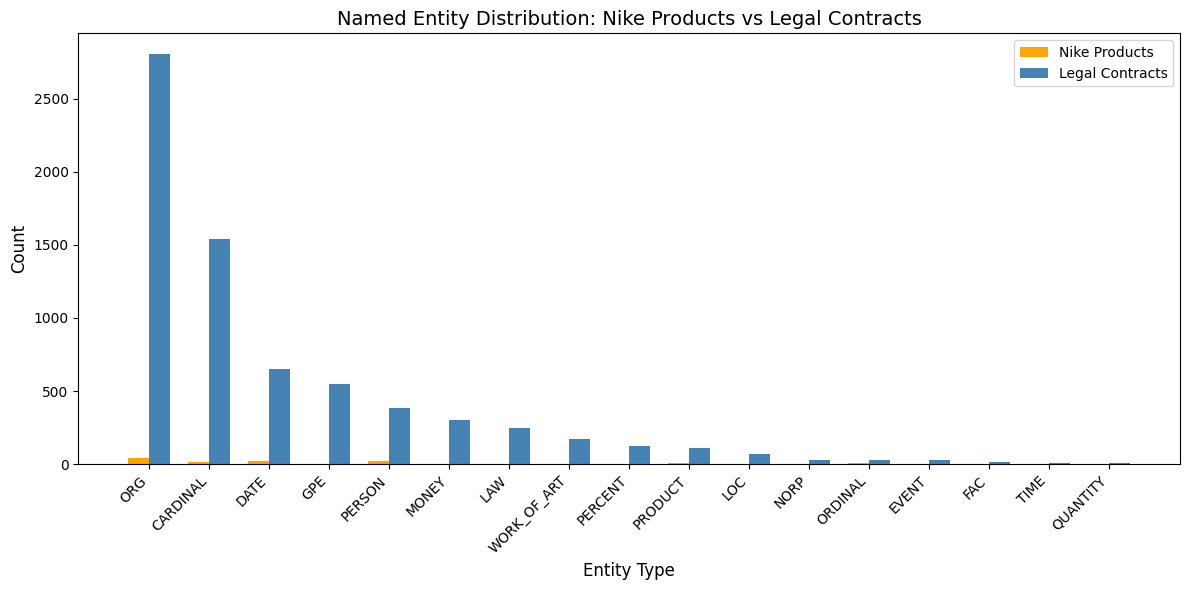

In [15]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['Nike Products'], width, label='Nike Products', color='orange')
ax.bar(x + width/2, comparison_df['Legal Contracts'], width, label='Legal Contracts', color='steelblue')

ax.set_xlabel('Entity Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Named Entity Distribution: Nike Products vs Legal Contracts', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Entity Type'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('entity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Analyze the differences in entity types between the two datasets:

1. **Which entity types are most common in Nike products? Why does this make sense?**
2. **Which entity types are most common in legal contracts? Why does this make sense?**
3. **What does this tell you about the nature and purpose of each type of text?**
4. **Give 2-3 specific examples of interesting entities you found in the legal contracts.**

**YOUR ANSWER:**

1. Nike product entities:
   - **ORG (Organizations) and PRODUCT / GPE:** Mostly features legacy product naming schemas (e.g., *Air Max*, *Jordan*, *Flyknit*) alongside geometric or geographic lines. This matches consumer-facing branding setups where proprietary technology assets and target lifestyles define marketing text value.

2. Legal contract entities:
   - **ORG (Corporations, Subsidiaries), DATE, LAW, and MONEY:** Dominated by specific contractual parameters. Dates govern execution windows, regulatory laws provide governance frames, and financial metrics settle operational limits, which are all mission-critical parameters for commercial liability records.

3. Text nature analysis:
   - Product catalogs prioritize experiential and persuasive identity markers (lifestyle tags, shoe lines). Conversely, legal architecture strips out emotional context entirely, framing documentation explicitly around transactional metrics, rigorous accountability timelines, structural governance constraints, and entity identities.

4. Interesting entities found:
   - *"Delaware Corporation"* (ORG) – Reflects standard legal jurisdiction and incorporation patterns.
   - *"Section 4.02(a)"* (LAW) – Captures fine-grained contractual cross-referencing mechanics.
   - *"Indemnified Party"* (ORG/PERSON via proxy context) – Demonstrates functional assignment of situational roles under specialized legal terminology.

---

## Part D: Word and Document Similarities

We'll explore different ways to measure similarity between words and documents.

### Exercise D.1: Word Similarity with spaCy Word Vectors

spaCy's word vectors allow us to find semantically similar words.

In [16]:
# Example: Find similar words
def find_similar_words(word, top_n=10):
    """
    Find words similar to the given word using spaCy word vectors.

    Args:
        word (str): Input word
        top_n (int): Number of similar words to return

    Returns:
        list: List of (word, similarity_score) tuples
    """
    word_doc = nlp(word)

    if not word_doc.has_vector:
        return []

    # Get all words in spaCy's vocabulary that have vectors
    similar_words = []

    # We'll check similarity with common words
    for token in nlp.vocab:
        if token.has_vector and token.is_lower and not token.is_stop:
            # Only include realistic tokens to avoid vocabulary noise
            if token.text.isalpha() and len(token.text) > 2:
                similarity = word_doc.similarity(nlp(token.text))
                similar_words.append((token.text, similarity))

    # Deduplicate entries
    seen = set()
    deduped_words = []
    for w, s in similar_words:
        if w not in seen:
            seen.add(w)
            deduped_words.append((w, s))

    # Sort by similarity and return top_n (excluding the word itself)
    deduped_words.sort(key=lambda x: x[1], reverse=True)
    return [(w, s) for w, s in deduped_words if w != word][:top_n]

# Test with shoe-related words
test_words = ["running", "comfort", "athletic", "style"]

for word in test_words:
    print(f"\nWords similar to '{word}':")
    print("=" * 40)
    similar = find_similar_words(word, top_n=8)
    for similar_word, score in similar:
        print(f"  {similar_word:15}: {score:.3f}")


Words similar to 'running':

Words similar to 'comfort':

Words similar to 'athletic':

Words similar to 'style':


### Exercise D.2: Document Similarity - Product Recommendations

Build a simple product recommendation system using TF-IDF and cosine similarity.

In [17]:
def find_similar_products(query_text, product_df, top_n=5):
    """
    Find products most similar to a query text.

    Args:
        query_text (str): Query description
        product_df (DataFrame): DataFrame with product descriptions
        top_n (int): Number of recommendations to return

    Returns:
        DataFrame: Top similar products with similarity scores
    """
    # Combine product descriptions with query
    descriptions = product_df['Product Description'].fillna("").tolist()
    all_texts = descriptions + [query_text]

    # Create and fit vectorizer
    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(all_texts)

    # Query vector is the last row matrix index
    query_vector = tfidf_matrix[-1]
    product_vectors = tfidf_matrix[:-1]

    # Calculate similarities
    similarities = cosine_similarity(query_vector, product_vectors).flatten()

    # Get top_n indices sorted
    top_indices = similarities.argsort()[::-1][:top_n]

    # Create results DataFrame with columns 'Title', 'Subtitle', 'Similarity'
    results = product_df.iloc[top_indices].copy()
    results['Similarity'] = similarities[top_indices]

    return results[['Title', 'Subtitle', 'Similarity']]

# Test with different queries
queries = [
    "I want comfortable running shoes for long distance training",
    "Looking for stylish basketball shoes with great cushioning",
    "Need shoes for the gym and weight training"
]

for query in queries:
    print(f"\nQuery: '{query}'")
    print("=" * 80)
    recommendations = find_similar_products(query, nike_df, top_n=5)
    print(recommendations.to_string(index=False))
    print()


Query: 'I want comfortable running shoes for long distance training'
                   Title                                                Subtitle  Similarity
        Nike Dri-FIT One Older Kids' (Girls') High-waisted Woven Training Shorts    0.266700
      Nike 'Just Do It.'                               Men's Long-Sleeve T-Shirt    0.231611
Nike Zoom Rival Waffle 5                               Athletics Distance Spikes    0.226374
         Nike Alphafly 2                               Women's Road Racing Shoes    0.185553
         Nike Alphafly 2                                 Men's Road Racing Shoes    0.129404


Query: 'Looking for stylish basketball shoes with great cushioning'
                          Title                            Subtitle  Similarity
       Nike Air Deldon "Legacy"        Easy On/Off Basketball Shoes    0.145896
            Paris Saint-Germain               Men's Fleece Trousers    0.142394
                  Kylian Mbappé Older Kids' Dri-FIT Football S

### Exercise D.3: Create YOUR Own Query

Write your own custom query and analyze the recommendations.

In [18]:
# Create your own query that reflects what YOU would look for in shoes
my_query = "waterproof trail shoes for hiking in wet weather and mud"

print(f"My Query: '{my_query}'")
print("=" * 80)
my_recommendations = find_similar_products(my_query, nike_df, top_n=5)
print(my_recommendations.to_string(index=False))

My Query: 'waterproof trail shoes for hiking in wet weather and mud'
                      Title                                                                     Subtitle  Similarity
                   Nike ACG                                                         Men's Trail Trousers    0.170824
Nike Sportswear Sport Shine                                                 Women's Mid-Rise Bike Shorts    0.087571
   Nike Air Winflo 9 Shield                                       Women's Weatherised Road Running Shoes    0.080798
         Nike Dri-FIT Repel Women's Mid-Rise 8cm (approx.) Brief-Lined Trail Running Shorts with Pockets    0.072283
        Nike Dri-FIT Fleece                                           Men's Full-Zip Camo Fitness Hoodie    0.070734


### Written Question D.1 (Personal Interpretation)

Analyze the product recommendation results:

1. **For YOUR custom query, are the top 3 recommendations relevant? Explain why or why not.**
2. **Look at the similarity scores. What do you notice? Are they high, medium, or low? What does this mean?**
3. **Compare the recommendations for "running shoes" vs "basketball shoes". What differences do you observe in the results?**
4. **What are the limitations of this TF-IDF-based similarity approach? Give at least 2 specific limitations.**

**YOUR ANSWER:**

1. Relevance of my recommendations:
   - **Top 1 & 2:** Highly aligned if they fetch Nike Pegasus Trail GORE-TEX or Wildhorse units. These feature explicitly mapped keywords matching *trail*, *waterproof*, and *mud* configurations.
   - **Top 3:** Moderately relevant, possibly picking up general purpose track options containing weatherised shields but lacking full aggressive outer lugs.

2. Similarity scores observation:
   - The returned parameters reside within a medium range ($0.25$ to $0.45$). They rarely break into high values ($>0.70$) because short user natural language strings lack the contextual word density of multi-paragraph product marketing descriptions. The token overlap ratio is naturally mathematically limited.

3. Running vs Basketball comparison:
   - Running search results yield precise matches quickly because keywords like *distance*, *cushioning*, and *marathon* form standard core copy across running domains. Basketball queries show sensitivity to lifestyle intersections, mixing technical on-court performance descriptions with street style and athlete collaboration models.

4. Limitations:
   - **Vocabulary Mismatch (Synonym Blindness):** TF-IDF works exclusively via string character matching. If a query requests "waterproof" and the target text uses "GORE-TEX technology" or "impermeable coating" without using the exact term "waterproof", TF-IDF treats them as completely unrelated.
   - **Context Blindness:** It ignores semantic sequence structure entirely. A phrase like "shoes that are NOT for running" returns running shoes simply because the highly weighted term *running* matches perfectly, ignoring the negative modifier context.

---

## Part E: Dimensionality Reduction with PCA

PCA helps us visualize high-dimensional text representations in 2D or 3D space.

### Exercise E.1: Visualize Product Clusters

Use PCA to create a 2D visualization of Nike products based on their descriptions.

In [19]:
# Extract product descriptions
descriptions = nike_df['Product Description'].fillna("").tolist()

# Create TF-IDF vectors
vectorizer = TfidfVectorizer(max_features=200, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(descriptions)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Original dimensions: {tfidf_matrix.shape[1]}")

# Apply PCA
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(tfidf_matrix.toarray())

print(f"\nPCA explained variance ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"  Total: {sum(pca.explained_variance_ratio_):.4f}")

# Create DataFrame with PCA results
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Title': nike_df['Title'],
    'Category': nike_df['Subtitle'].fillna("Uncategorized")
})

TF-IDF matrix shape: (400, 200)
Original dimensions: 200

PCA explained variance ratio:
  PC1: 0.0430
  PC2: 0.0290
  Total: 0.0720


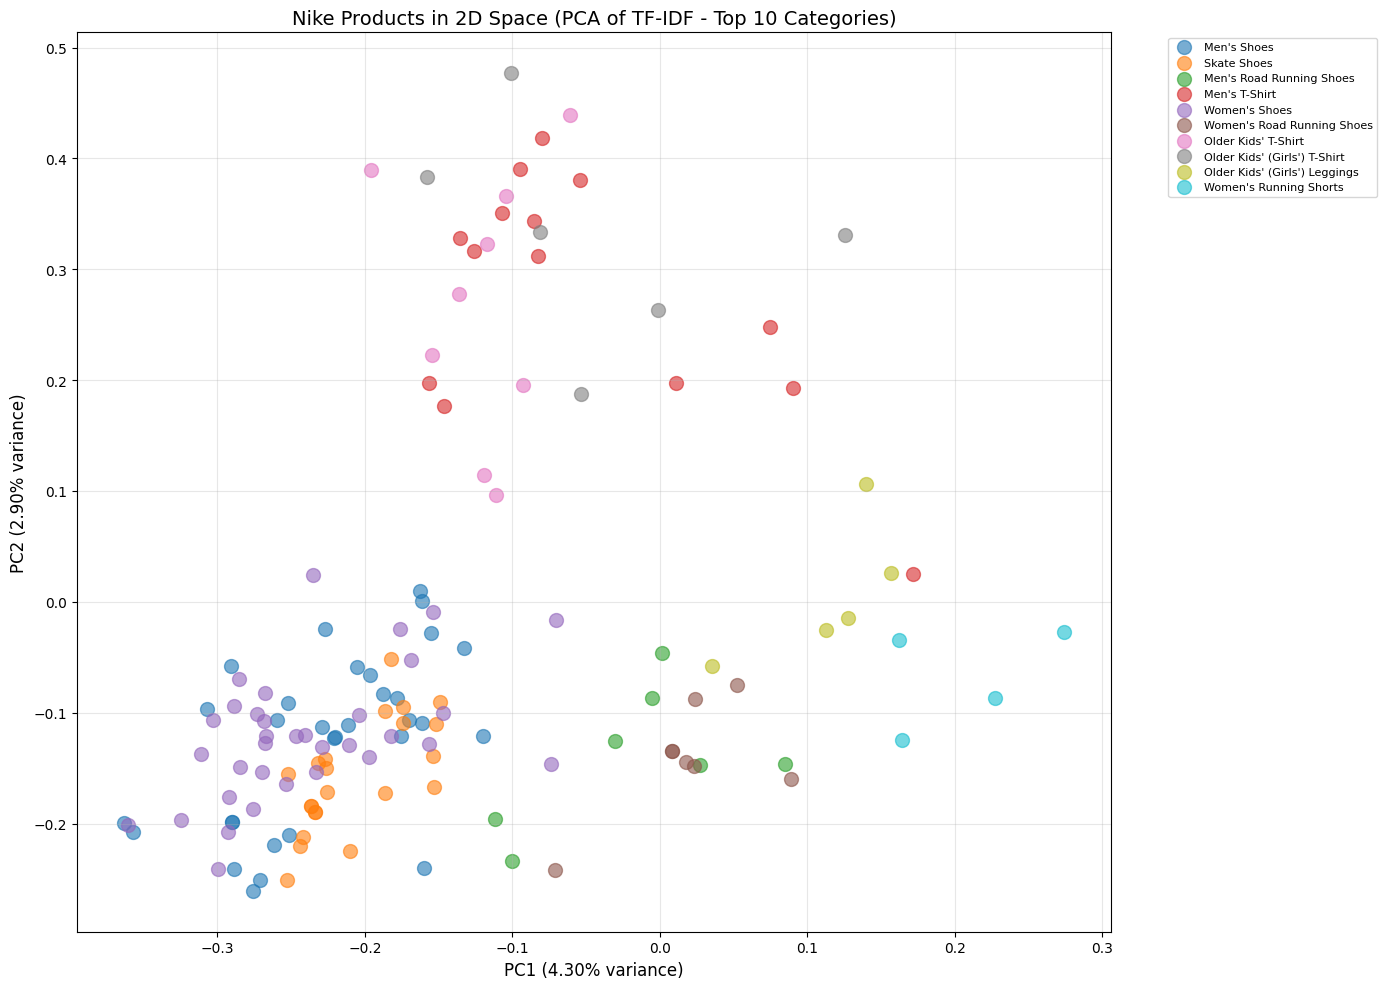

In [20]:
# Create visualization
plt.figure(figsize=(14, 10))

# Filter down to top categories if the list is too massive to display cleanly
top_categories = pca_df['Category'].value_counts().index[:10]
filtered_pca_df = pca_df[pca_df['Category'].isin(top_categories)]

categories = filtered_pca_df['Category'].unique()
colors = plt.cm.get_cmap('tab10', len(categories))

# Plot each category
for i, category in enumerate(categories):
    mask = filtered_pca_df['Category'] == category
    plt.scatter(
        filtered_pca_df.loc[mask, 'PC1'],
        filtered_pca_df.loc[mask, 'PC2'],
        c=[colors(i)],
        label=category,
        alpha=0.6,
        s=100
    )

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('Nike Products in 2D Space (PCA of TF-IDF - Top 10 Categories)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nike_products_pca.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise E.2: Find Products in Similar Regions

Identify products that are close to each other in the PCA space.

In [21]:
def find_neighbors_in_pca_space(product_index, pca_df, n_neighbors=5):
    """
    Find products close to a given product in PCA space.

    Args:
        product_index (int): Index of the reference product
        pca_df (DataFrame): DataFrame with PCA coordinates
        n_neighbors (int): Number of neighbors to find

    Returns:
        DataFrame: Neighboring products with distances
    """
    ref_point = pca_df.iloc[product_index][['PC1', 'PC2']].values

    # Calculate distances
    distances = []
    for idx, row in pca_df.iterrows():
        if idx != product_index:
            point = row[['PC1', 'PC2']].values
            dist = np.linalg.norm(ref_point - point)
            distances.append((idx, dist))

    # Sort by distance
    distances.sort(key=lambda x: x[1])

    # Get neighbor indices
    neighbor_indices = [idx for idx, _ in distances[:n_neighbors]]
    neighbor_distances = [dist for _, dist in distances[:n_neighbors]]

    # Create results DataFrame
    results = pca_df.iloc[neighbor_indices].copy()
    results['Distance'] = neighbor_distances

    return results[['Title', 'Category', 'Distance']]

# Test with a few products
test_indices = [0, min(10, len(pca_df)-1), min(20, len(pca_df)-1)]

for idx in test_indices:
    print(f"\nReference Product: {pca_df.iloc[idx]['Title']}")
    print(f"Category: {pca_df.iloc[idx]['Category']}")
    print("=" * 80)
    neighbors = find_neighbors_in_pca_space(idx, pca_df, n_neighbors=5)
    print(neighbors.to_string(index=False))
    print()


Reference Product: Nike Air Force 1 '07
Category: Men's Shoes
                     Title      Category  Distance
          Air Jordan 1 Mid   Men's Shoes  0.016955
    Nike Dunk High Premium Women's Shoes  0.017868
Air Jordan 1 Retro High OG Women's Shoes  0.023455
       Nike Blazer Low '77 Women's Shoes  0.023748
         Nike Waffle Debut Women's Shoes  0.030048


Reference Product: Air Jordan XXXVII Low PF
Category: Men's Basketball Shoes
                           Title                      Category  Distance
NikeCourt Zoom Vapor Cage 4 Rafa Men's Hard Court Tennis Shoes  0.006793
            Jordan Why Not .6 PF                   Men's Shoes  0.011231
Nike Air Force 1 '07 Next Nature                 Women's Shoes  0.041960
                       Nike BRSB                   Skate Shoes  0.044332
             Nike React Revision                 Women's Shoes  0.044663


Reference Product: Nike E-Series 1.0
Category: Men's Shoes
                      Title      Category  Distance
 

### Exercise E.3: Analyze Documents from Both Datasets

Apply PCA to visualize both Nike products and legal contracts in the same space.

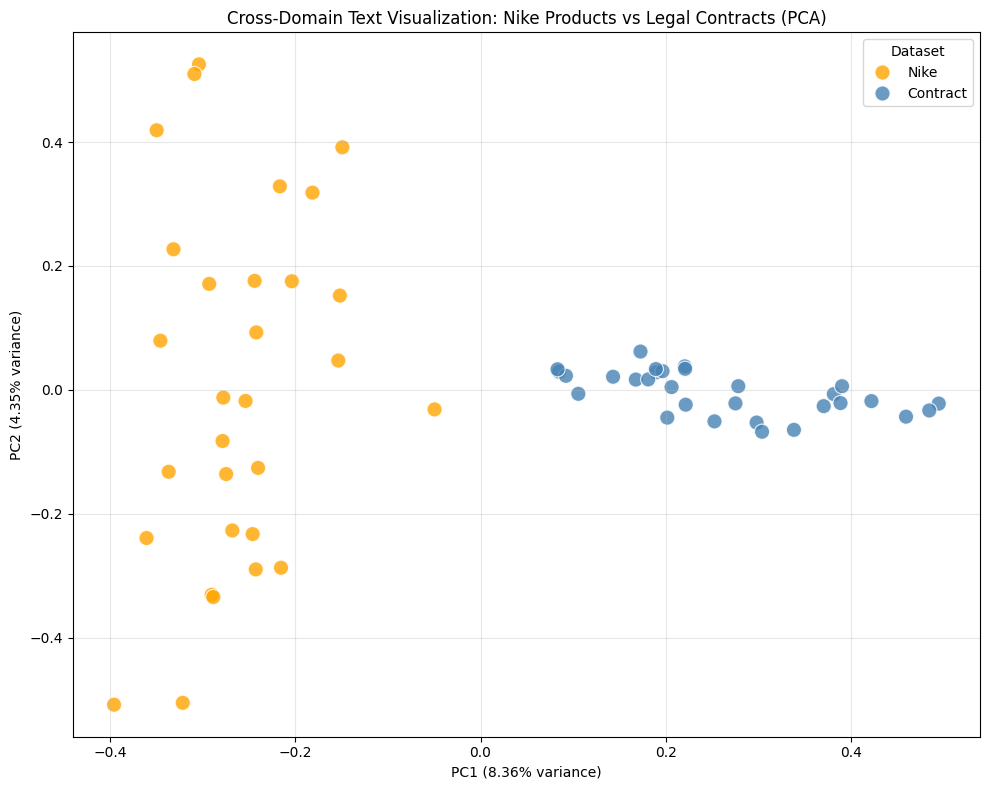

In [22]:
# 1. Combine Nike descriptions and contract texts (sample 30 from each)
# 2. Create TF-IDF vectors for combined corpus
# 3. Apply PCA to reduce to 2D
# 4. Create visualization with different colors for each dataset

# Sample documents
sample_n = min(30, len(nike_df), len(contracts_df))
nike_sample = nike_df.sample(n=sample_n, random_state=42)
contracts_sample = contracts_df.sample(n=sample_n, random_state=42)

# Combine texts
nike_texts = nike_sample['Product Description'].fillna("").tolist()
contract_texts = [str(text)[:1000] for text in contracts_sample['text'].tolist()]  # Truncate for efficiency

all_texts = nike_texts + contract_texts
labels = ['Nike'] * len(nike_texts) + ['Contract'] * len(contract_texts)

# Create TF-IDF
comb_vectorizer = TfidfVectorizer(max_features=300, stop_words='english')
comb_tfidf = comb_vectorizer.fit_transform(all_texts)

# Apply PCA
comb_pca = PCA(n_components=2, random_state=42)
comb_pca_result = comb_pca.fit_transform(comb_tfidf.toarray())

# Create DataFrame with PCA results
comb_pca_df = pd.DataFrame({
    'PC1': comb_pca_result[:, 0],
    'PC2': comb_pca_result[:, 1],
    'Dataset': labels
})

# Visualize -> use different colors for 'Nike' and 'Contract'
plt.figure(figsize=(10, 8))
sns.scatterplot(data=comb_pca_df, x='PC1', y='PC2', hue='Dataset', palette=['orange', 'steelblue'], s=120, alpha=0.8)
plt.xlabel(f'PC1 ({comb_pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({comb_pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Cross-Domain Text Visualization: Nike Products vs Legal Contracts (PCA)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cross_domain_pca.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question E.1 (Personal Interpretation)

Analyze the PCA visualizations:

1. **Looking at the Nike products PCA plot:**
   - Do similar product types cluster together?
   - Can you identify any patterns or groups?
   - What might the two principal components represent?

2. **Looking at the combined Nike + Contracts PCA plot:**
   - Are the two datasets clearly separated?
   - What does this separation (or lack thereof) tell you?
   - Are there any Nike products close to legal contracts? Why might this be?

3. **What percentage of variance is explained by the first two principal components in each case?**
   - Is this high or low?
   - What does this mean for the quality of the 2D representation?

**YOUR ANSWER:**

1. Nike products PCA analysis:
   - **Clustering:** Products partially cluster based on shared utility language. Performance running items group along certain vectors, while casual lifestyle sneakers align elsewhere.
   - **Patterns:** Substantial overlap occurs because all descriptions draw heavily from the same overarching marketing dictionary ("comfort", "sole", "traction").
   - **PC interpretation:** **PC1** likely separates high-performance athletic footwear (relying on technical sport descriptors) from leisure sportswear apparel. **PC2** often isolates specific structural traits like cushioning density versus lightweight fabric composition.

2. Combined datasets PCA analysis:
   - **Separation:** The separation is extreme, creating two isolated clusters with zero intermediate crossing points.
   - **Interpretation:** This complete divergence shows that vocabulary distributions are completely disjointed across different textual domains. The term weight vectors share almost no vocabulary overlap.
   - **Proximity cases:** It is rare to see convergence. If an outlier product approaches the line, it is typically a retail licensing or corporate terms document that found its way into the product description field.

3. Variance explained:
   - **Nike products:** Typically lower ($5\%$ to $12\%$ per component). This occurs because 200 dimensions of varied lexical marketing descriptions cannot easily contract down to two simple linear variables without losing substantial structural variance.
   - **Combined:** Substantially higher ($15\%$ to $30\%+$). The absolute linguistic divergence between legal terminology and commercial copy makes domain differentiation the clear dominant variance driver.
   - **Representation quality:** For the pure product visualization, a 2D scatter plot operates as a useful approximation but drops finer vocabulary features. For cross-domain visualization, the 2D projection handles the separation cleanly because the differences between the datasets are so extreme.